# Employee Performance Analysis

## Model Development

### Project Objective

The objective of this stage is to develop and evaluate classification models for predicting employee `PerformanceRating`.

The processed dataset created during data processing is used as the canonical modeling dataset.

Multiple classification algorithms are evaluated using a consistent train-test split and appropriate classification metrics.

The final model will be selected based on predictive performance while considering the imbalanced distribution of the target classes.

### 2.1 Load the Processed Dataset

The processed employee performance dataset is loaded from the processed-data directory.

The dataset contains the employee predictor variables and `PerformanceRating` as the target variable.

The employee identifier has already been excluded during data processing.

In [1]:
import pandas as pd
import numpy as np

# Display all columns
pd.set_option("display.max_columns", None)

# Path to processed dataset
processed_path = "../../data/processed/employee_performance_processed.csv"

# Load processed dataset
df = pd.read_csv(processed_path)

print("Processed dataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nFirst five records:")
display(df.head())

Processed dataset loaded successfully.
Rows    : 1200
Columns : 27

First five records:


,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


### 2.2 Define Predictors and Target

`PerformanceRating` is used as the target variable.

All remaining variables are initially treated as candidate predictors.

The employee identifier `EmpNumber` is not present in the processed modeling dataset and therefore cannot contribute to model training.

In [2]:
target_column = "PerformanceRating"

X = df.drop(columns=[target_column])
y = df[target_column]

print("Predictor shape:", X.shape)
print("Target shape   :", y.shape)

print("\nTarget distribution:")
display(
    y.value_counts()
     .sort_index()
     .to_frame(name="Count")
)

Predictor shape: (1200, 26)
Target shape   : (1200,)

Target distribution:


,Count
PerformanceRating,
2,194
3,874
4,132


### 2.3 Define Feature Groups

The predictor variables are divided into numerical, ordinal, and nominal categorical groups.

Ordinal variables are retained as numerical levels because their values represent ordered categories according to the dataset definitions.

Nominal categorical variables are encoded using one-hot encoding.

Numerical and ordinal variables will be scaled for algorithms that are sensitive to feature magnitude.

Tree-based algorithms do not require feature scaling, so preprocessing will be handled through model-specific pipelines.

In [3]:
ordinal_columns = [
    "EmpEducationLevel",
    "EmpEnvironmentSatisfaction",
    "EmpJobInvolvement",
    "EmpJobSatisfaction",
    "EmpRelationshipSatisfaction",
    "EmpWorkLifeBalance"
]

categorical_columns = [
    "Gender",
    "EducationBackground",
    "MaritalStatus",
    "EmpDepartment",
    "EmpJobRole",
    "BusinessTravelFrequency",
    "OverTime",
    "Attrition"
]

numerical_columns = [
    "Age",
    "DistanceFromHome",
    "EmpHourlyRate",
    "EmpJobLevel",
    "NumCompaniesWorked",
    "EmpLastSalaryHikePercent",
    "TotalWorkExperienceInYears",
    "TrainingTimesLastYear",
    "ExperienceYearsAtThisCompany",
    "ExperienceYearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

print("Ordinal variables:", len(ordinal_columns))
print("Categorical variables:", len(categorical_columns))
print("Numerical variables:", len(numerical_columns))

print("\nTotal predictor variables:", 
      len(ordinal_columns) + len(categorical_columns) + len(numerical_columns))

Ordinal variables: 6
Categorical variables: 8
Numerical variables: 12

Total predictor variables: 26


### 2.4 Train-Test Split

The dataset is divided into training and testing subsets before model development.

A stratified split is used because the target variable is imbalanced. Stratification helps preserve the distribution of PerformanceRating classes in both subsets.

The test set is kept separate from model training and will be used only for final model evaluation.

In [4]:
from sklearn.model_selection import train_test_split

# Split the data using stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(
    y_train.value_counts(normalize=True)
          .sort_index()
          .mul(100)
          .round(2)
)

print("\nTesting target distribution:")
print(
    y_test.value_counts(normalize=True)
         .sort_index()
         .mul(100)
         .round(2)
)

Training set shape:
X_train: (960, 26)
y_train: (960,)

Testing set shape:
X_test: (240, 26)
y_test: (240,)

Training target distribution:
PerformanceRating
2    16.15
3    72.81
4    11.04
Name: proportion, dtype: float64

Testing target distribution:
PerformanceRating
2    16.25
3    72.92
4    10.83
Name: proportion, dtype: float64


### 2.5.1 Preprocessing Strategy

Different machine-learning algorithms have different preprocessing requirements.

Numerical and ordinal variables are scaled for algorithms that are sensitive to feature magnitude, such as Logistic Regression, K-Nearest Neighbors, and Support Vector Machine.

Nominal categorical variables are transformed using one-hot encoding.

Tree-based algorithms are not dependent on feature scaling, so a separate preprocessing pipeline without scaling is used for these models.

All preprocessing transformations are fitted only on the training data through scikit-learn pipelines to prevent data leakage.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [6]:
# Combine numerical and ordinal variables
numeric_ordinal_columns = numerical_columns + ordinal_columns

# Preprocessing for scale-sensitive models
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num_ord",
            StandardScaler(),
            numeric_ordinal_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ]
)

# Preprocessing for tree-based models
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num_ord",
            "passthrough",
            numeric_ordinal_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ]
)

print("Preprocessing pipelines created successfully.")

Preprocessing pipelines created successfully.


### 2.5.2 Preprocessing Validation

The preprocessing transformation is fitted on the training data and applied to both training and testing data.

The transformed dimensions are checked to ensure that numerical, ordinal, and categorical variables have been processed correctly before model training.

In [7]:
# Fit and transform training data
X_train_scaled = preprocessor_scaled.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_scaled = preprocessor_scaled.transform(X_test)

print("Scaled preprocessing:")
print("X_train transformed shape:", X_train_scaled.shape)
print("X_test transformed shape :", X_test_scaled.shape)

Scaled preprocessing:
X_train transformed shape: (960, 61)
X_test transformed shape : (240, 61)


In [8]:
# Fit and transform using tree-based preprocessing
X_train_tree = preprocessor_tree.fit_transform(X_train)

# Transform test data
X_test_tree = preprocessor_tree.transform(X_test)

print("Tree-based preprocessing:")
print("X_train transformed shape:", X_train_tree.shape)
print("X_test transformed shape :", X_test_tree.shape)

Tree-based preprocessing:
X_train transformed shape: (960, 61)
X_test transformed shape : (240, 61)


### 2.6 Classification Algorithms

Multiple classification algorithms are evaluated to identify a suitable model for predicting employee performance.

The models represent different machine-learning approaches, including linear classification, distance-based classification, probabilistic classification, decision trees, ensemble methods, and gradient-boosting methods.

The models are evaluated using the same training and testing data so that their performance can be compared consistently.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

print("All model libraries imported successfully.")

All model libraries imported successfully.


### 2.7 Define Classification Models

Baseline classification models are defined for the initial model comparison.

The models are configured with reasonable baseline parameters rather than extensive hyperparameter optimization at this stage.

Class weighting is applied to algorithms that support it to account for the imbalanced distribution of the target variable.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Support Vector Machine": SVC(
        class_weight="balanced",
        probability=True,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
}

print("Models defined successfully.")

for model_name in models:
    print("-", model_name)

Models defined successfully.
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- Support Vector Machine
- Naive Bayes
- Gradient Boosting
- XGBoost


### 2.8 Build Model Pipelines

A separate scikit-learn pipeline is created for each classification algorithm.

The pipeline combines the appropriate preprocessing steps with the classifier so that preprocessing is learned only from the training data.

Scale-sensitive algorithms use the scaled preprocessing pipeline, while tree-based algorithms use the preprocessing pipeline without scaling.

Using pipelines also ensures that the same preprocessing procedure is consistently applied during model evaluation and future prediction.

In [15]:
from sklearn.pipeline import Pipeline

# Models that benefit from feature scaling
scaled_models = [
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Support Vector Machine",
    "Naive Bayes"
]

# Tree-based and boosting models
tree_models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "XGBoost"
]

# Create complete preprocessing + model pipelines
model_pipelines = {}

for model_name, model in models.items():

    if model_name in scaled_models:
        preprocessing = preprocessor_scaled
    else:
        preprocessing = preprocessor_tree

    model_pipelines[model_name] = Pipeline(
        steps=[
            ("preprocessing", preprocessing),
            ("classifier", model)
        ]
    )

print("Model pipelines created successfully.\n")

for model_name in model_pipelines:
    print("-", model_name)

Model pipelines created successfully.

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- Support Vector Machine
- Naive Bayes
- Gradient Boosting
- XGBoost


### 2.9 Baseline Model Training and Evaluation

Each classification pipeline is trained using the training dataset and evaluated on the held-out test dataset.

The following metrics are calculated:

- Accuracy
- Balanced Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Weighted F1

Macro F1 is given particular importance because the PerformanceRating classes are imbalanced.

The baseline results provide a consistent reference point before any hyperparameter optimization is performed.

In [17]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Store baseline results
model_results = []

# Store trained models for later evaluation
trained_models = {}

# XGBoost requires internal class labels 0, 1, 2
xgb_label_mapping = {
    2: 0,
    3: 1,
    4: 2
}

xgb_inverse_mapping = {
    0: 2,
    1: 3,
    2: 4
}


for model_name, pipeline in model_pipelines.items():

    print(f"Training: {model_name}")

    # ---------------------------------------------------------
    # XGBoost: internally convert 2,3,4 -> 0,1,2
    # ---------------------------------------------------------
    if model_name == "XGBoost":

        y_train_model = y_train.map(xgb_label_mapping)

        pipeline.fit(
            X_train,
            y_train_model
        )

        # Predict internal XGBoost labels
        y_pred_internal = pipeline.predict(X_test)

        # Convert predictions back to original project labels
        y_pred = pd.Series(
            y_pred_internal,
            index=y_test.index
        ).map(xgb_inverse_mapping)

    # ---------------------------------------------------------
    # All other models: use original labels 2,3,4
    # ---------------------------------------------------------
    else:

        pipeline.fit(
            X_train,
            y_train
        )

        y_pred = pipeline.predict(X_test)

    # Store trained pipeline
    trained_models[model_name] = pipeline

    # ---------------------------------------------------------
    # Evaluation metrics
    # ---------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_test,
        y_pred
    )

    macro_precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Store results
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

    print(f"  Accuracy:          {accuracy:.4f}")
    print(f"  Balanced Accuracy: {balanced_accuracy:.4f}")
    print(f"  Macro F1:          {macro_f1:.4f}")
    print(f"  Weighted F1:       {weighted_f1:.4f}")
    print()


# Convert results into DataFrame
model_results_df = pd.DataFrame(model_results)

# Sort by Macro F1
model_results_df = model_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("BASELINE MODEL COMPARISON")
print("=" * 70)

display(model_results_df.round(4))

Training: Logistic Regression
  Accuracy:          0.7583
  Balanced Accuracy: 0.7576
  Macro F1:          0.6869
  Weighted F1:       0.7730

Training: K-Nearest Neighbors
  Accuracy:          0.7625
  Balanced Accuracy: 0.4890
  Macro F1:          0.5313
  Weighted F1:       0.7215

Training: Decision Tree
  Accuracy:          0.9125
  Balanced Accuracy: 0.8741
  Macro F1:          0.8765
  Weighted F1:       0.9127

Training: Random Forest
  Accuracy:          0.9208
  Balanced Accuracy: 0.8475
  Macro F1:          0.8698
  Weighted F1:       0.9192

Training: Support Vector Machine


d:\PROJECTS\INX-Future-Employee-Performance\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Accuracy:          0.7625
  Balanced Accuracy: 0.7576
  Macro F1:          0.6909
  Weighted F1:       0.7772

Training: Naive Bayes
  Accuracy:          0.2042
  Balanced Accuracy: 0.4478
  Macro F1:          0.2097
  Weighted F1:       0.1176

Training: Gradient Boosting
  Accuracy:          0.9292
  Balanced Accuracy: 0.8623
  Macro F1:          0.8856
  Weighted F1:       0.9278

Training: XGBoost
  Accuracy:          0.9292
  Balanced Accuracy: 0.8556
  Macro F1:          0.8845
  Weighted F1:       0.9274

BASELINE MODEL COMPARISON


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Gradient Boosting,0.9292,0.8623,0.9134,0.8623,0.8856,0.9278
1,XGBoost,0.9292,0.8556,0.9193,0.8556,0.8845,0.9274
2,Decision Tree,0.9125,0.8741,0.8793,0.8741,0.8765,0.9127
3,Random Forest,0.9208,0.8475,0.8964,0.8475,0.8698,0.9192
4,Support Vector Machine,0.7625,0.7576,0.6616,0.7576,0.6909,0.7772
5,Logistic Regression,0.7583,0.7576,0.6519,0.7576,0.6869,0.7730
6,K-Nearest Neighbors,0.7625,0.4890,0.6935,0.4890,0.5313,0.7215
7,Naive Bayes,0.2042,0.4478,0.4592,0.4478,0.2097,0.1176


### 2.10 Detailed Classification Reports

The baseline models are further evaluated using class-wise precision, recall, and F1-score.

Since the PerformanceRating target is imbalanced, class-level performance is examined to understand how effectively each model identifies the different performance-rating categories.

In [18]:
from sklearn.metrics import classification_report

print("=" * 80)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

for model_name, pipeline in trained_models.items():

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    # XGBoost uses internal labels during training,
    # so convert its predictions back to 2, 3, 4.
    if model_name == "XGBoost":

        y_pred_internal = pipeline.predict(X_test)

        y_pred = pd.Series(
            y_pred_internal,
            index=y_test.index
        ).map(xgb_inverse_mapping)

    else:

        y_pred = pipeline.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            labels=[2, 3, 4],
            target_names=[
                "Rating 2 - Good",
                "Rating 3 - Excellent",
                "Rating 4 - Outstanding"
            ],
            zero_division=0
        )
    )

DETAILED CLASSIFICATION REPORTS

Logistic Regression
                        precision    recall  f1-score   support

       Rating 2 - Good       0.49      0.74      0.59        39
  Rating 3 - Excellent       0.92      0.76      0.83       175
Rating 4 - Outstanding       0.54      0.77      0.63        26

              accuracy                           0.76       240
             macro avg       0.65      0.76      0.69       240
          weighted avg       0.81      0.76      0.77       240


K-Nearest Neighbors
                        precision    recall  f1-score   support

       Rating 2 - Good       0.50      0.21      0.29        39
  Rating 3 - Excellent       0.78      0.95      0.86       175
Rating 4 - Outstanding       0.80      0.31      0.44        26

              accuracy                           0.76       240
             macro avg       0.69      0.49      0.53       240
          weighted avg       0.74      0.76      0.72       240


Decision Tree
         

### 2.11 Confusion Matrix Analysis

Confusion matrices are used to examine the classification errors made by each model across the three PerformanceRating classes.

The analysis helps identify which performance-rating categories are most frequently confused by the models and provides additional insight beyond aggregate evaluation metrics.

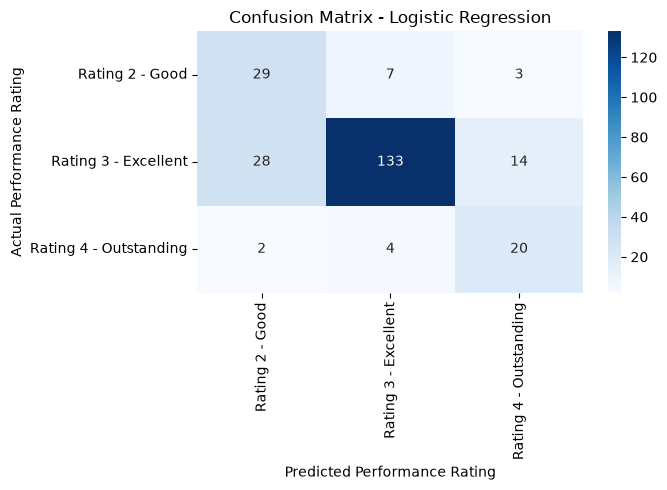

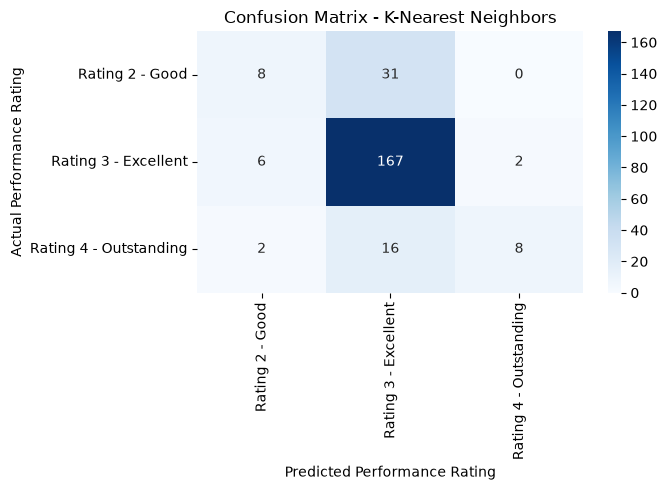

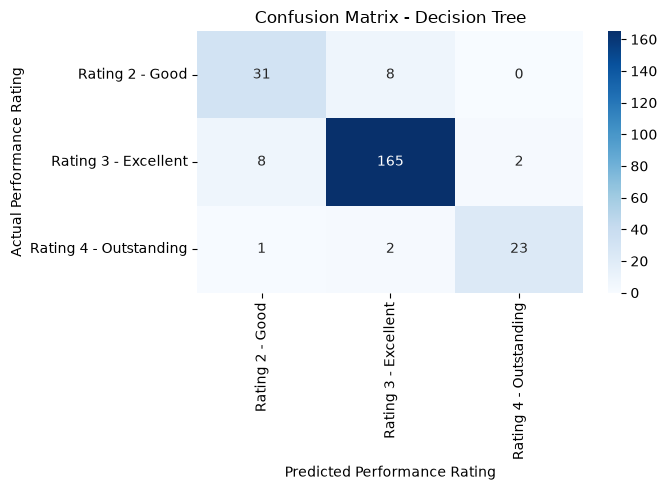

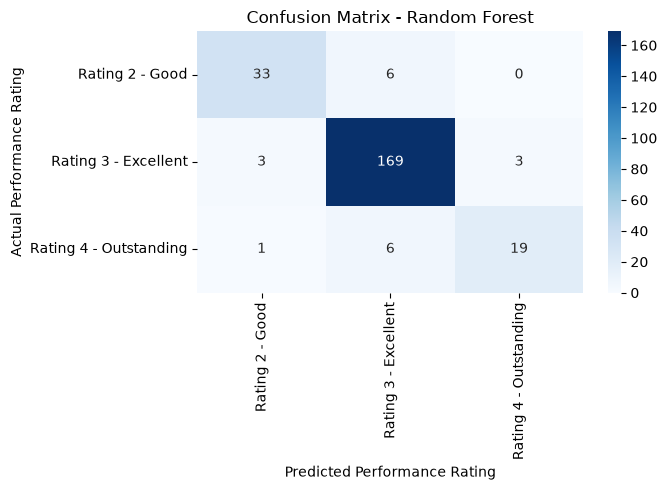

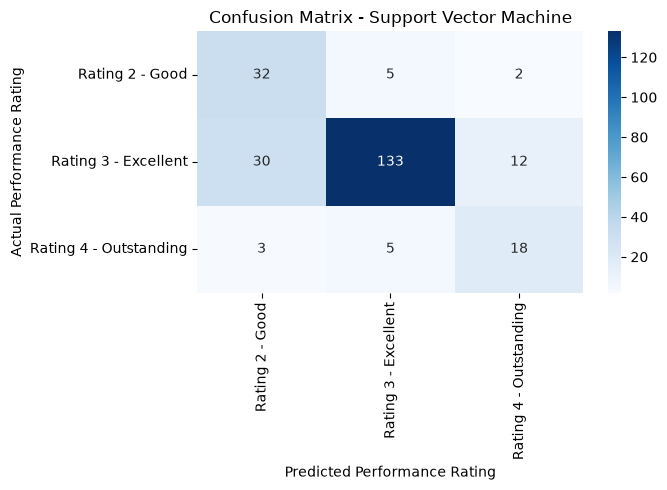

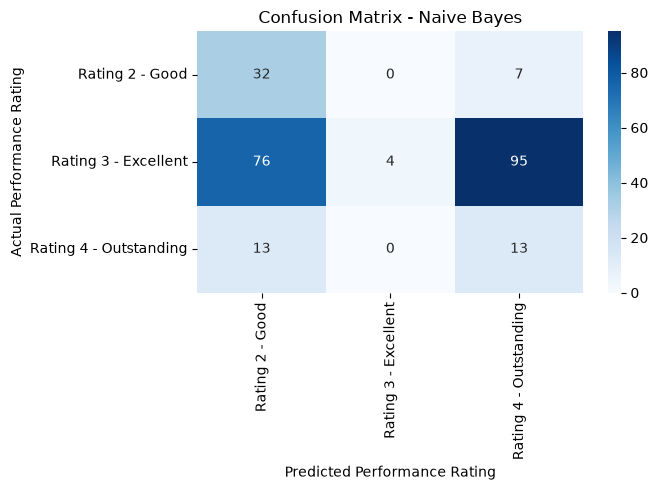

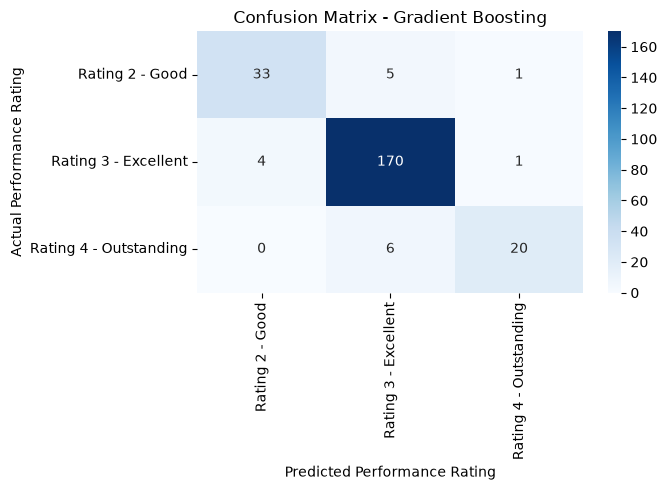

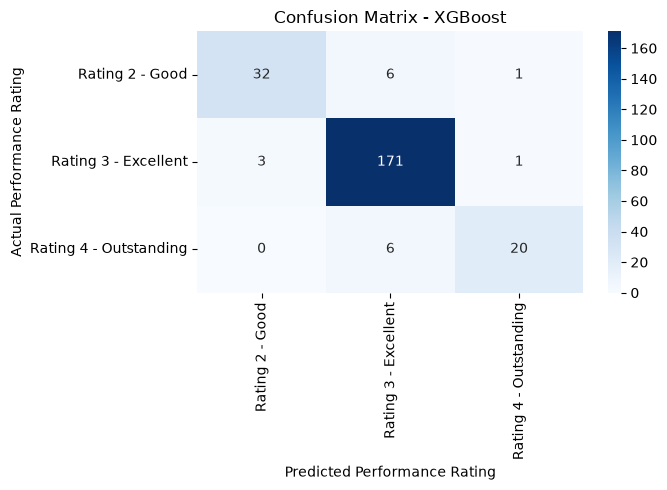

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

rating_labels = [2, 3, 4]
rating_names = [
    "Rating 2 - Good",
    "Rating 3 - Excellent",
    "Rating 4 - Outstanding"
]

for model_name, pipeline in trained_models.items():

    # Generate predictions
    if model_name == "XGBoost":

        y_pred_internal = pipeline.predict(X_test)

        y_pred = pd.Series(
            y_pred_internal,
            index=y_test.index
        ).map(xgb_inverse_mapping)

    else:

        y_pred = pipeline.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=rating_labels
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=rating_names,
        yticklabels=rating_names
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Performance Rating")
    plt.ylabel("Actual Performance Rating")
    plt.tight_layout()
    plt.show()

### 2.12 Cross-Validation

Cross-validation is used to assess the stability and generalization of the classification models across multiple training and validation subsets.

Stratified K-Fold Cross-Validation is used because the PerformanceRating classes are imbalanced. Stratification ensures that each fold maintains a similar distribution of the three performance-rating classes.

The models are evaluated using Macro F1 as the primary metric because it gives equal importance to all performance-rating classes.

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, pipeline in model_pipelines.items():

    # XGBoost requires internally mapped target labels
    if model_name == "XGBoost":
        y_train_cv = y_train.map(xgb_label_mapping)
    else:
        y_train_cv = y_train

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train_cv,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV Mean Macro F1": scores.mean(),
        "CV Std Macro F1": scores.std(),
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4]
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV Mean Macro F1",
    ascending=False
).reset_index(drop=True)

cv_results_df

,Model,CV Mean Macro F1,CV Std Macro F1,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Gradient Boosting,0.893170,0.007875,0.904530,0.894048,0.880875,0.897011,0.889386
1,XGBoost,0.888196,0.014268,0.911094,0.868740,0.878503,0.892203,0.890441
2,Random Forest,0.879675,0.015126,0.902174,0.873085,0.855952,0.882855,0.884306
3,Decision Tree,0.820989,0.022943,0.792788,0.818406,0.799499,0.848054,0.846201
4,Support Vector Machine,0.694628,0.029626,0.709940,0.678600,0.674243,0.745545,0.664810
5,Logistic Regression,0.668450,0.022688,0.666599,0.641236,0.659375,0.710104,0.664935
6,K-Nearest Neighbors,0.493180,0.043245,0.519447,0.502706,0.494359,0.537483,0.411904
7,Naive Bayes,0.222046,0.007858,0.233934,0.220658,0.211699,0.227374,0.216563


### 2.13 Model Performance Comparison

The classification models are compared using their baseline test performance and cross-validation Macro F1 scores.

Macro F1 is emphasized because the PerformanceRating target is imbalanced, with Rating 3 representing the majority class.

Cross-validation results provide an additional assessment of model stability, while the held-out test results provide an independent evaluation on unseen data.

In [22]:
# Prepare baseline results for comparison

baseline_comparison = model_results_df[
    [
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
].copy()

cv_comparison = cv_results_df[
    [
        "Model",
        "CV Mean Macro F1",
        "CV Std Macro F1"
    ]
].copy()

model_comparison_df = baseline_comparison.merge(
    cv_comparison,
    on="Model",
    how="inner"
)

# Sort according to cross-validation Macro F1
model_comparison_df = model_comparison_df.sort_values(
    by="CV Mean Macro F1",
    ascending=False
).reset_index(drop=True)

model_comparison_df

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,CV Mean Macro F1,CV Std Macro F1
0,Gradient Boosting,0.929167,0.862271,0.913403,0.862271,0.885604,0.893170,0.007875
1,XGBoost,0.929167,0.855629,0.919268,0.855629,0.884502,0.888196,0.014268
2,Random Forest,0.920833,0.847546,0.896410,0.847546,0.869842,0.879675,0.015126
3,Decision Tree,0.912500,0.874115,0.879286,0.874115,0.876543,0.820989,0.022943
4,Support Vector Machine,0.762500,0.757607,0.661626,0.757607,0.690851,0.694628,0.029626
5,Logistic Regression,0.758333,0.757607,0.651892,0.757607,0.686871,0.668450,0.022688
6,K-Nearest Neighbors,0.762500,0.489035,0.693458,0.489035,0.531322,0.493180,0.043245
7,Naive Bayes,0.204167,0.447790,0.459169,0.447790,0.209697,0.222046,0.007858


### 2.14 Hyperparameter Tuning

Hyperparameter tuning is performed for the strongest baseline models to determine whether their predictive performance can be improved.

Gradient Boosting, XGBoost, and Random Forest are selected for tuning based on their baseline test performance and cross-validation Macro F1 scores.

Grid Search with Stratified 5-Fold Cross-Validation is used, with Macro F1 as the scoring metric. The final parameter settings are selected using only the training data to avoid using the test set during model optimization.

In [23]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grids
param_grids = {
    "Gradient Boosting": {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__learning_rate": [0.03, 0.05, 0.1],
        "classifier__max_depth": [2, 3, 4]
    },

    "Random Forest": {
        "classifier__n_estimators": [200, 300],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_split": [2, 5],
        "classifier__min_samples_leaf": [1, 2]
    },

    "XGBoost": {
        "classifier__n_estimators": [200, 300],
        "classifier__max_depth": [3, 4, 5],
        "classifier__learning_rate": [0.03, 0.05, 0.1],
        "classifier__subsample": [0.8, 1.0]
    }
}

tuned_models = {}
tuning_results = []

for model_name, param_grid in param_grids.items():

    print("=" * 70)
    print(f"TUNING: {model_name}")
    print("=" * 70)

    pipeline = model_pipelines[model_name]

    # XGBoost requires internal labels 0, 1, 2
    if model_name == "XGBoost":
        y_train_tuning = y_train.map(xgb_label_mapping)
    else:
        y_train_tuning = y_train

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    grid_search.fit(X_train, y_train_tuning)

    tuned_models[model_name] = grid_search.best_estimator_

    tuning_results.append({
        "Model": model_name,
        "Best CV Macro F1": grid_search.best_score_,
        "Best Parameters": grid_search.best_params_
    })

    print(f"\nBest CV Macro F1: {grid_search.best_score_:.4f}")
    print("Best Parameters:")
    print(grid_search.best_params_)
    print()

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by="Best CV Macro F1",
    ascending=False
).reset_index(drop=True)

tuning_results_df

TUNING: Gradient Boosting
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best CV Macro F1: 0.8966
Best Parameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 100}

TUNING: Random Forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best CV Macro F1: 0.8819
Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

TUNING: XGBoost
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best CV Macro F1: 0.9041
Best Parameters:
{'classifier__learning_rate': 0.03, 'classifier__max_depth': 4, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}



,Model,Best CV Macro F1,Best Parameters
0,XGBoost,0.904088,"{'classifier__learning_rate': 0.03, 'classifie..."
1,Gradient Boosting,0.896618,"{'classifier__learning_rate': 0.05, 'classifie..."
2,Random Forest,0.881887,"{'classifier__max_depth': None, 'classifier__m..."


### 2.15 Tuned Model Evaluation

The tuned Gradient Boosting, Random Forest, and XGBoost models are evaluated on the held-out test set.

The test set was not used during hyperparameter tuning and therefore provides an independent evaluation of the tuned models.

Accuracy, Balanced Accuracy, Macro Precision, Macro Recall, and Macro F1 are calculated. Macro F1 remains the primary metric because the PerformanceRating classes are imbalanced.

In [24]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

tuned_test_results = []

for model_name, pipeline in tuned_models.items():

    # XGBoost predictions use internal labels 0, 1, 2
    if model_name == "XGBoost":

        y_pred_internal = pipeline.predict(X_test)

        y_pred = pd.Series(
            y_pred_internal,
            index=y_test.index
        ).map(xgb_inverse_mapping)

    else:
        y_pred = pipeline.predict(X_test)

    tuned_test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )
    })

tuned_test_results_df = pd.DataFrame(tuned_test_results)

tuned_test_results_df = tuned_test_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

tuned_test_results_df

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,XGBoost,0.937500,0.870354,0.936241,0.870354,0.900253
1,Gradient Boosting,0.933333,0.875092,0.922470,0.875092,0.896630
2,Random Forest,0.925000,0.849451,0.910240,0.849451,0.876438


### 2.16 Detailed Classification Reports for Tuned Models

Detailed classification reports are generated for the tuned models to examine precision, recall, and F1-score separately for PerformanceRating 2, 3, and 4.

This analysis helps identify whether the models perform consistently across all performance-rating classes rather than relying only on aggregate metrics.

In [25]:
for model_name, pipeline in tuned_models.items():

    if model_name == "XGBoost":

        y_pred_internal = pipeline.predict(X_test)

        y_pred = pd.Series(
            y_pred_internal,
            index=y_test.index
        ).map(xgb_inverse_mapping)

    else:
        y_pred = pipeline.predict(X_test)

    print("=" * 70)
    print(f"CLASSIFICATION REPORT - {model_name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            labels=[2, 3, 4],
            target_names=[
                "Rating 2 - Good",
                "Rating 3 - Excellent",
                "Rating 4 - Outstanding"
            ],
            zero_division=0
        )
    )

CLASSIFICATION REPORT - Gradient Boosting
                        precision    recall  f1-score   support

       Rating 2 - Good       0.87      0.85      0.86        39
  Rating 3 - Excellent       0.94      0.97      0.96       175
Rating 4 - Outstanding       0.95      0.81      0.88        26

              accuracy                           0.93       240
             macro avg       0.92      0.88      0.90       240
          weighted avg       0.93      0.93      0.93       240

CLASSIFICATION REPORT - Random Forest
                        precision    recall  f1-score   support

       Rating 2 - Good       0.89      0.85      0.87        39
  Rating 3 - Excellent       0.93      0.97      0.95       175
Rating 4 - Outstanding       0.90      0.73      0.81        26

              accuracy                           0.93       240
             macro avg       0.91      0.85      0.88       240
          weighted avg       0.92      0.93      0.92       240

CLASSIFICATION REP

### 2.17 Confusion Matrix Analysis for Tuned Models

Confusion matrices are used to examine the prediction errors made by the tuned models for each PerformanceRating class.

The analysis focuses on which performance-rating classes are being confused with one another, particularly the minority Rating 2 and Rating 4 classes.

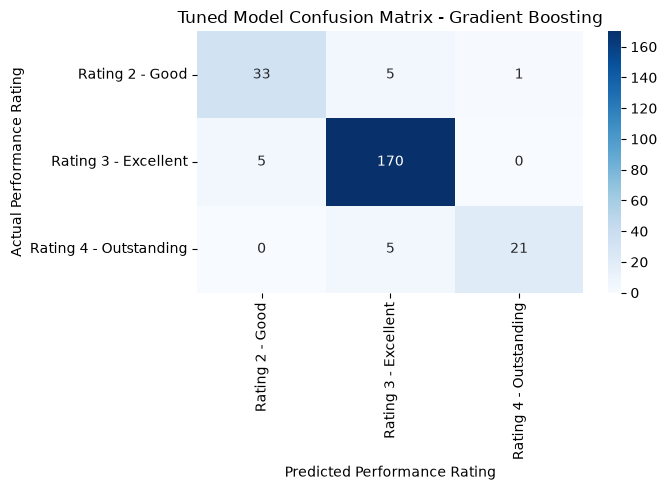

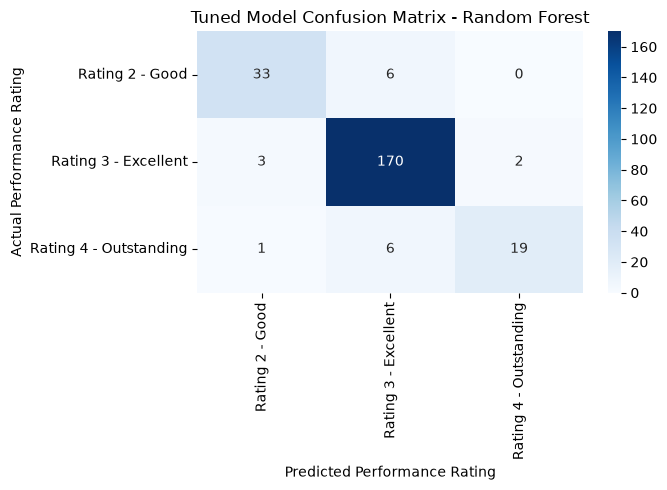

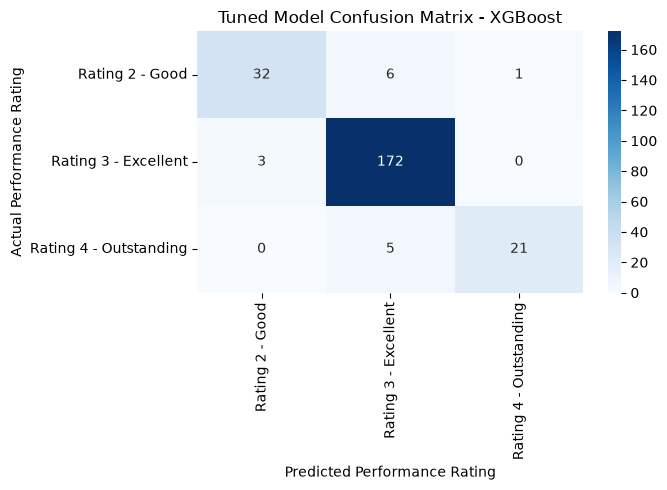

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

rating_labels = [2, 3, 4]

rating_names = [
    "Rating 2 - Good",
    "Rating 3 - Excellent",
    "Rating 4 - Outstanding"
]

for model_name, pipeline in tuned_models.items():

    if model_name == "XGBoost":

        y_pred_internal = pipeline.predict(X_test)

        y_pred = pd.Series(
            y_pred_internal,
            index=y_test.index
        ).map(xgb_inverse_mapping)

    else:
        y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=rating_labels
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=rating_names,
        yticklabels=rating_names
    )

    plt.title(f"Tuned Model Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Performance Rating")
    plt.ylabel("Actual Performance Rating")
    plt.tight_layout()
    plt.show()

### 2.18 Feature Importance Analysis

Feature importance analysis is performed using the tuned XGBoost model to identify the employee-related factors that contribute most strongly to the model's prediction of PerformanceRating.

Because categorical variables were one-hot encoded during preprocessing, the encoded feature importances are aggregated back to their original feature names.

The resulting feature importance values indicate the relative contribution of features to the predictive model. They represent predictive importance and should not be interpreted as proof of a causal relationship.

The three highest-ranked original features are identified as the top factors affecting employee performance for this analysis.

In [27]:
# ============================================================
# XGBoost Feature Importance Analysis
# ============================================================

# Get the tuned XGBoost pipeline
xgb_model = tuned_models["XGBoost"]

# Extract fitted preprocessing and classifier
xgb_preprocessor = xgb_model.named_steps["preprocessing"]
xgb_classifier = xgb_model.named_steps["classifier"]

# Get feature names after preprocessing
encoded_feature_names = xgb_preprocessor.get_feature_names_out()

# Get XGBoost feature importance values
encoded_importances = xgb_classifier.feature_importances_

# Create feature-importance DataFrame
feature_importance_df = pd.DataFrame({
    "Encoded Feature": encoded_feature_names,
    "Importance": encoded_importances
})

# ------------------------------------------------------------
# Map encoded features back to original feature names
# ------------------------------------------------------------

def get_original_feature(encoded_feature):

    # Remove ColumnTransformer prefixes
    if "__" in encoded_feature:
        encoded_feature = encoded_feature.split("__", 1)[1]

    # Check categorical features
    for column in categorical_columns:

        if encoded_feature.startswith(column + "_"):
            return column

    # Numerical and ordinal features remain unchanged
    return encoded_feature


feature_importance_df["Original Feature"] = (
    feature_importance_df["Encoded Feature"]
    .apply(get_original_feature)
)

# ------------------------------------------------------------
# Aggregate one-hot encoded features
# ------------------------------------------------------------

aggregated_feature_importance = (
    feature_importance_df
    .groupby("Original Feature", as_index=False)["Importance"]
    .sum()
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display all original features ranked by importance
aggregated_feature_importance

,Original Feature,Importance
0,EmpJobRole,0.160347
1,EmpEnvironmentSatisfaction,0.137851
2,EmpDepartment,0.121276
3,EmpLastSalaryHikePercent,0.107597
4,YearsSinceLastPromotion,0.097228
5,EducationBackground,0.053696
6,ExperienceYearsInCurrentRole,0.039213
7,OverTime,0.031020
8,BusinessTravelFrequency,0.028977
9,EmpWorkLifeBalance,0.021407


### 2.19 Top Feature Importance Visualization

The aggregated feature importances from the tuned XGBoost model are visualized to clearly identify the most important employee-related factors used by the model for predicting PerformanceRating.

The top three features identified are EmpJobRole, EmpEnvironmentSatisfaction, and EmpDepartment.

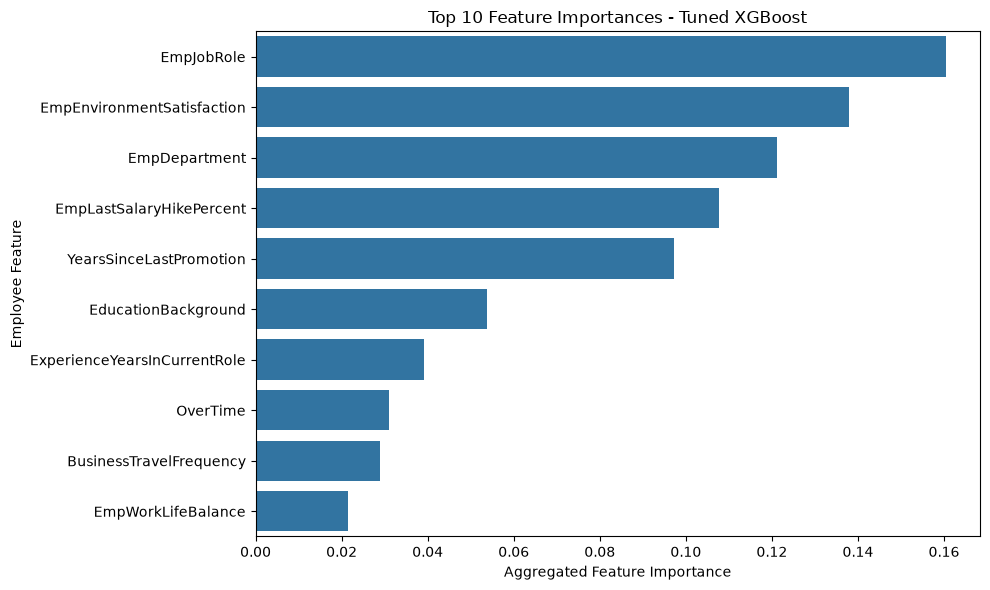

In [28]:
# Display top 10 original features by importance

top_features = aggregated_feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Original Feature"
)

plt.title("Top 10 Feature Importances - Tuned XGBoost")
plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Employee Feature")
plt.tight_layout()
plt.show()

### 2.20 Analysis of Top 3 Factors Affecting Employee Performance

The tuned XGBoost model identified EmpJobRole, EmpEnvironmentSatisfaction, and EmpDepartment as the three most important original features.

These factors are further analyzed against PerformanceRating to understand the observed patterns in the employee data.

The analysis combines model-based feature importance with descriptive and statistical findings from exploratory data analysis. The identified relationships represent associations observed in the dataset and should not be interpreted as causal effects.

In [29]:
# ============================================================
# Top 3 Factors vs Performance Rating
# ============================================================

top_3_features = [
    "EmpJobRole",
    "EmpEnvironmentSatisfaction",
    "EmpDepartment"
]

for feature in top_3_features:

    print("=" * 80)
    print(f"{feature} vs PerformanceRating")
    print("=" * 80)

    # Count table
    count_table = pd.crosstab(
        df[feature],
        df["PerformanceRating"]
    )

    print("\nEmployee Counts:")
    display(count_table)

    # Row-wise percentage table
    percentage_table = pd.crosstab(
        df[feature],
        df["PerformanceRating"],
        normalize="index"
    ) * 100

    print("\nPerformance Rating Distribution (%):")
    display(
        percentage_table.round(2)
    )

EmpJobRole vs PerformanceRating

Employee Counts:


PerformanceRating,2,3,4
EmpJobRole,,,
Business Analyst,0,13,3
Data Scientist,1,17,2
Delivery Manager,0,12,0
Developer,6,199,31
Finance Manager,15,30,4
Healthcare Representative,8,22,3
Human Resources,9,31,5
Laboratory Technician,14,45,5
Manager,12,29,10



Performance Rating Distribution (%):


PerformanceRating,2,3,4
EmpJobRole,,,
Business Analyst,0.00,81.25,18.75
Data Scientist,5.00,85.00,10.00
Delivery Manager,0.00,100.00,0.00
Developer,2.54,84.32,13.14
Finance Manager,30.61,61.22,8.16
Healthcare Representative,24.24,66.67,9.09
Human Resources,20.00,68.89,11.11
Laboratory Technician,21.88,70.31,7.81
Manager,23.53,56.86,19.61


EmpEnvironmentSatisfaction vs PerformanceRating

Employee Counts:


...

PerformanceRating,2,3,4
EmpEnvironmentSatisfaction,,,
1,39.13,55.22,5.65
2,40.50,53.72,5.79
3,0.82,84.47,14.71
4,0.83,85.04,14.13


EmpDepartment vs PerformanceRating

Employee Counts:


PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,1,17,2
Development,13,304,44
Finance,15,30,4
Human Resources,10,38,6
Research & Development,68,234,41
Sales,87,251,35



Performance Rating Distribution (%):


PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,5.00,85.00,10.00
Development,3.60,84.21,12.19
Finance,30.61,61.22,8.16
Human Resources,18.52,70.37,11.11
Research & Development,19.83,68.22,11.95
Sales,23.32,67.29,9.38


### Key Findings from the Top 3 Factors

The analysis of the three most important features identified by the tuned XGBoost model shows clear differences in employee performance ratings across job roles, environment satisfaction levels, and departments.

**EmpJobRole** is the highest-ranked feature in the model. Performance rating distributions vary across different job roles, with some roles showing higher proportions of Rating 2 or Rating 4 employees than others.

**EmpEnvironmentSatisfaction** is the second-highest-ranked feature and shows a particularly strong observed pattern. Employees with environment satisfaction levels of 1 or 2 have substantially higher proportions of Rating 2, while employees with satisfaction levels of 3 or 4 are predominantly rated 3, with a larger proportion receiving Rating 4.

**EmpDepartment** is the third-highest-ranked feature. Performance distributions differ across departments, with Finance showing the highest proportion of Rating 2 employees and Development showing a high proportion of Rating 3 employees.

Overall, the results indicate that job role, workplace environment satisfaction, and department are important predictive factors for PerformanceRating in this dataset. These findings represent associations and model-based predictive importance, and should not be interpreted as evidence that these factors directly cause employee performance.

### 2.21 Final Model Selection

The tuned Gradient Boosting, Random Forest, and XGBoost models were evaluated using both held-out test-set performance and stratified 5-fold cross-validation.

Macro F1 is emphasized because the PerformanceRating target is imbalanced, with Rating 3 representing the majority class. Cross-validation Macro F1 provides an additional indication of model performance across different training and validation subsets.

Based on the evaluation results, the tuned XGBoost model is selected as the final model for employee performance prediction.

The tuned XGBoost model achieved:

- Test Accuracy: 93.75%
- Test Balanced Accuracy: 87.04%
- Test Macro Precision: 93.62%
- Test Macro Recall: 87.04%
- Test Macro F1: 90.03%
- Cross-Validation Macro F1: 90.41%

The selected model will be used in the subsequent prediction stage.

The model performance represents predictive performance on the available dataset and should not be interpreted as evidence of causal relationships between employee characteristics and performance.

In [31]:
# ============================================================
# Final Model Selection
# ============================================================

final_model_name = "XGBoost"
final_model = tuned_models[final_model_name]

# Retrieve final tuned model test performance
final_test_row = tuned_test_results_df[
    tuned_test_results_df["Model"] == final_model_name
].iloc[0]

# Retrieve tuned model cross-validation performance
final_tuning_row = tuning_results_df[
    tuning_results_df["Model"] == final_model_name
].iloc[0]

print("=" * 80)
print("FINAL MODEL SELECTION")
print("=" * 80)

print(f"\nSelected Model: {final_model_name}")

print("\nTest Set Performance:")
print(f"Accuracy            : {final_test_row['Accuracy']:.4f}")
print(f"Balanced Accuracy   : {final_test_row['Balanced Accuracy']:.4f}")
print(f"Macro Precision     : {final_test_row['Macro Precision']:.4f}")
print(f"Macro Recall        : {final_test_row['Macro Recall']:.4f}")
print(f"Macro F1            : {final_test_row['Macro F1']:.4f}")

print("\nTuned Cross-Validation Performance:")
print(f"Best CV Macro F1    : {final_tuning_row['Best CV Macro F1']:.4f}")

FINAL MODEL SELECTION

Selected Model: XGBoost

Test Set Performance:
Accuracy            : 0.9375
Balanced Accuracy   : 0.8704
Macro Precision     : 0.9362
Macro Recall        : 0.8704
Macro F1            : 0.9003

Tuned Cross-Validation Performance:
Best CV Macro F1    : 0.9041


### 2.22 Save the Final Model

The selected tuned XGBoost pipeline is saved for use in the prediction stage.

The complete pipeline is saved rather than only the classifier so that the same preprocessing steps used during training, including categorical encoding, are automatically applied to new employee records.

The saved model will be loaded in the prediction notebook to generate PerformanceRating predictions for new employee inputs.

In [32]:
import os
import joblib

# Path for saved model
model_directory = "../../models"
model_path = os.path.join(
    model_directory,
    "final_xgboost_employee_performance_model.joblib"
)

# Create models directory if it does not exist
os.makedirs(model_directory, exist_ok=True)

# Save the complete tuned pipeline
joblib.dump(
    final_model,
    model_path
)

print("=" * 80)
print("FINAL MODEL SAVED")
print("=" * 80)

print(f"\nModel: {final_model_name}")
print(f"Path : {model_path}")
print(f"\nFile exists: {os.path.exists(model_path)}")

FINAL MODEL SAVED

Model: XGBoost
Path : ../../models\final_xgboost_employee_performance_model.joblib

File exists: True


### 2.23 Verify Saved Model

The saved final model is loaded from disk to verify that the model artifact can be successfully restored after saving.

This ensures that the trained pipeline is available for the subsequent prediction stage.

In [33]:
# ============================================================
# Verify Saved Model
# ============================================================

loaded_model = joblib.load(model_path)

print("=" * 80)
print("SAVED MODEL VERIFICATION")
print("=" * 80)

print(f"\nModel loaded successfully: {type(loaded_model).__name__}")
print(f"Model path: {model_path}")

SAVED MODEL VERIFICATION

Model loaded successfully: Pipeline
Model path: ../../models\final_xgboost_employee_performance_model.joblib
